# Salary Visualization EDA với Matplotlib và Seaborn

Notebook này dùng `data/analysis/salary_analysis_clean.csv` để học visualization trước khi đi vào Linear Regression.

Mục tiêu không phải là vẽ thật đẹp, mà là biết dùng chart để trả lời: salary có lệch không, có outlier không, feature nào có tín hiệu, và field nào chưa đủ sạch để đưa vào model.

## 0. Matplotlib vs Seaborn

- `matplotlib` là thư viện nền: tạo figure, axis, title, label, layout.
- `seaborn` là lớp tiện dụng phía trên matplotlib: viết ít code hơn cho EDA/statistical plots.
- Pattern nên nhớ: tạo `fig, ax = plt.subplots(...)`, rồi truyền `ax=ax` vào seaborn. Cách này giúp kiểm soát chart rõ hơn.

In [1]:
from pathlib import Path
import ast
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid", context="notebook")


def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "analysis" / "salary_analysis_clean.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing data/analysis/salary_analysis_clean.csv")


REPO_ROOT = find_repo_root()
SALARY_PATH = REPO_ROOT / "data" / "analysis" / "salary_analysis_clean.csv"

print(f"Repo root: {REPO_ROOT}")
print(f"Salary file: {SALARY_PATH}")

Repo root: G:\project\Vietnam IT Job Market Intelligence
Salary file: G:\project\Vietnam IT Job Market Intelligence\data\analysis\salary_analysis_clean.csv


## 1. Load Data

Trước khi vẽ chart, luôn kiểm tra số dòng, số cột, và một vài cột chính. Đây là bước giúp tránh vẽ nhầm dataset.

In [2]:
salary = pd.read_csv(SALARY_PATH, encoding="utf-8-sig")

print(f"Rows: {len(salary):,}")
print(f"Columns: {len(salary.columns):,}")
display(salary[["source", "title", "company", "location", "salary_raw", "salary_currency", "salary_period", "salary_midpoint", "seniority", "experience_min"]].head(10))

Rows: 504
Columns: 40


,source,title,company,location,salary_raw,salary_currency,salary_period,salary_midpoint,seniority,experience_min
0,itviec,10 Fullstack Deverloper (Java/ Spring Boot/Angular),Thien Hoang Solutions JSC,Hà Nội,1200 - 1600 USD,USD,month,1400.0,middle,4.0
1,itviec,[10] Nhân sự đánh giá rò quét lỗ hổng ANTT (Pentest),TRUNG TÂM THÔNG TIN TÍN DỤNG QUỐC GIA VIỆT NAM (CIC),Hà Nội,800 - 1500 USD,USD,month,1150.0,middle,2.0
2,itviec,[11] Nhân sự săn tìm mối nguy (Thread huntting),TRUNG TÂM THÔNG TIN TÍN DỤNG QUỐC GIA VIỆT NAM (CIC),Hà Nội,800 - 1500 USD,USD,month,1150.0,middle,2.0
3,itviec,"20 Java Backend Devs (Spring Boot, Hibernate, Oracle)",Thien Hoang Solutions JSC,Hà Nội,1100 - 1900 USD,USD,month,1500.0,middle,3.0
4,itviec,AI Agent Engineer (Contract): Build the Agent Layer,Panto Martech LLC,Hồ Chí Minh,2500 - 4000 USD,USD,month,3250.0,NaN,NaN
5,itviec,"AI Agent Engineer (Python, LLM)",KDS Vietnam,Hồ Chí Minh,1300 - 1800 USD,USD,month,1550.0,middle,3.0
6,itviec,AI Engineer (Định hướng Data Scientist),KALAPA,Hà Nội,600 - 1300 USD,USD,month,950.0,middle,2.0
7,itviec,Middle AI Engineer (Inference Engineering),Autonomous,Hồ Chí Minh,1000 - 2000 USD,USD,month,1500.0,middle,1.0
8,itviec,AI Engineer (Machine Learning/LLM/API),CLUEGA,Hồ Chí Minh,"18M-65,5M",VND,month,41750000.0,middle,2.0
9,itviec,AI Engineer with Leading Korean AI Entrepreneurs,Abc Studio Việt Nam,Hồ Chí Minh,1000 - 2000 USD,USD,month,1500.0,middle,3.0


## 2. Chuẩn Bị Data Cho Chart

Chart salary sẽ dễ đọc hơn nếu đưa mọi lương về cùng đơn vị. Ở notebook này ta tạo biến phân tích tạm thời, không ghi đè file gốc.

Lưu ý quan trọng: dataset hiện tại có một số dòng `salary_period = year` do parser đọc chữ `năm/year` trong mô tả kinh nghiệm. Vì `salary_raw` không ghi annual/year rõ ràng, notebook này tạo `salary_period_clean` và tạm coi các dòng đó là monthly để phục vụ EDA/model baseline.

In [3]:
USD_TO_VND = 26_000

salary_chart = salary.copy()


def strip_accents(value):
    if pd.isna(value):
        return ""
    value = str(value).replace("Đ", "D").replace("đ", "d")
    return "".join(character for character in unicodedata.normalize("NFD", value) if unicodedata.category(character) != "Mn")


def fold_text(value):
    return strip_accents(value).casefold().strip()


def clean_text_series(series):
    cleaned = series.astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
    return cleaned.mask(cleaned.eq(""), pd.NA)


def normalize_location(value):
    folded = fold_text(value)
    if re.search(r"\b(?:tp\.?\s*)?(?:hcm|ho chi minh|thanh pho ho chi minh|sai gon)\b", folded):
        return "Ho Chi Minh"
    if re.search(r"\b(?:ha noi|hanoi)\b", folded):
        return "Ha Noi"
    if re.search(r"\b(?:da nang|danang)\b", folded):
        return "Da Nang"
    if not folded or folded == "nan":
        return "Unknown"
    return str(value).strip()


def to_listish(value):
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, list):
                return [str(item).strip() for item in parsed if str(item).strip()]
        except (ValueError, SyntaxError):
            pass
    return [part.strip() for part in text.replace(";", ",").split(",") if part.strip()]


skill_alias = {
    "js": "javascript",
    "reactjs": "react",
    "react.js": "react",
    "vuejs": "vue",
    "vue.js": "vue",
    "node": "node.js",
    "nodejs": "node.js",
    "golang": "go",
    "postgres": "postgresql",
    "k8s": "kubernetes",
    "ts": "typescript",
    "csharp": "c#",
    "dotnet": ".net",
    "html5": "html",
    "css3": "css",
}


def normalize_skill(value):
    folded = fold_text(value).replace("&", " and ")
    folded = re.sub(r"\s+", " ", folded).strip()
    return skill_alias.get(folded, folded)


for column in ["source", "title", "company", "location", "salary_raw", "salary_currency", "salary_period", "seniority", "work_mode", "skills"]:
    if column in salary_chart.columns:
        salary_chart[column] = clean_text_series(salary_chart[column])

for column in ["salary_min", "salary_max", "salary_midpoint", "experience_min", "experience_max"]:
    salary_chart[column] = pd.to_numeric(salary_chart[column], errors="coerce")

salary_chart["scraped_at_dt"] = pd.to_datetime(salary_chart["scraped_at"], errors="coerce", utc=True, format="mixed")
salary_chart["posted_at_dt"] = pd.to_datetime(salary_chart["posted_at"], errors="coerce", utc=True, format="mixed")
salary_chart["posted_age_days"] = (salary_chart["scraped_at_dt"] - salary_chart["posted_at_dt"]).dt.days

salary_raw_folded = salary_chart["salary_raw"].map(fold_text)
raw_has_annual_signal = salary_raw_folded.str.contains(r"\b(?:year|annual|annually|nam)\b", na=False)
salary_chart["salary_period_clean"] = salary_chart["salary_period"].astype("string")
salary_chart.loc[salary_chart["salary_period_clean"].eq("year") & ~raw_has_annual_signal, "salary_period_clean"] = "month"

salary_chart["salary_monthly_vnd"] = salary_chart["salary_midpoint"]
usd_mask = salary_chart["salary_currency"].astype("string").str.upper().eq("USD")
annual_mask = salary_chart["salary_period_clean"].eq("year") & raw_has_annual_signal
salary_chart.loc[usd_mask, "salary_monthly_vnd"] = salary_chart.loc[usd_mask, "salary_monthly_vnd"] * USD_TO_VND
salary_chart.loc[annual_mask, "salary_monthly_vnd"] = salary_chart.loc[annual_mask, "salary_monthly_vnd"] / 12
salary_chart["salary_monthly_vnd_m"] = salary_chart["salary_monthly_vnd"] / 1_000_000
salary_chart["log_salary_monthly_vnd"] = np.log(salary_chart["salary_monthly_vnd"].where(salary_chart["salary_monthly_vnd"].gt(0)))

salary_chart["location_norm"] = salary_chart["location"].map(normalize_location).astype("string")
salary_chart["skills_list"] = salary_chart["skills"].apply(to_listish)
salary_chart["skills_norm_list"] = salary_chart["skills_list"].apply(lambda values: sorted({normalize_skill(value) for value in values if normalize_skill(value)}))
salary_chart["skill_count"] = salary_chart["skills_norm_list"].str.len()

period_audit = pd.crosstab(salary_chart["salary_period"], salary_chart["salary_period_clean"], dropna=False)
display(period_audit)
display(salary_chart[["source", "salary_raw", "salary_currency", "salary_period", "salary_period_clean", "salary_midpoint", "salary_monthly_vnd_m", "location", "location_norm", "skill_count"]].head(10))

salary_period_clean,month
salary_period,
month,403
year,101


,source,salary_raw,salary_currency,salary_period,salary_period_clean,salary_midpoint,salary_monthly_vnd_m,location,location_norm,skill_count
0,itviec,1200 - 1600 USD,USD,month,month,1400.0,36.40,Hà Nội,Ha Noi,12
1,itviec,800 - 1500 USD,USD,month,month,1150.0,29.90,Hà Nội,Ha Noi,3
2,itviec,800 - 1500 USD,USD,month,month,1150.0,29.90,Hà Nội,Ha Noi,3
3,itviec,1100 - 1900 USD,USD,month,month,1500.0,39.00,Hà Nội,Ha Noi,14
4,itviec,2500 - 4000 USD,USD,month,month,3250.0,84.50,Hồ Chí Minh,Ho Chi Minh,7
5,itviec,1300 - 1800 USD,USD,month,month,1550.0,40.30,Hồ Chí Minh,Ho Chi Minh,7
6,itviec,600 - 1300 USD,USD,month,month,950.0,24.70,Hà Nội,Ha Noi,4
7,itviec,1000 - 2000 USD,USD,month,month,1500.0,39.00,Hồ Chí Minh,Ho Chi Minh,7
8,itviec,"18M-65,5M",VND,month,month,41750000.0,41.75,Hồ Chí Minh,Ho Chi Minh,10
9,itviec,1000 - 2000 USD,USD,month,month,1500.0,39.00,Hồ Chí Minh,Ho Chi Minh,6


## 3. Countplot: Số Mẫu Theo Source

`countplot` dùng để kiểm tra dataset có bị lệch nguồn không. Nếu một source chiếm quá nhiều, model có thể học bias của source thay vì quy luật chung của thị trường.

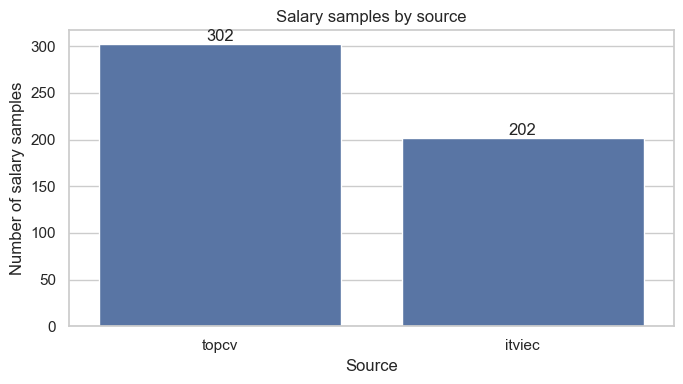

In [4]:
source_order = salary_chart["source"].value_counts().index

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=salary_chart, x="source", order=source_order, ax=ax)
ax.set_title("Salary samples by source")
ax.set_xlabel("Source")
ax.set_ylabel("Number of salary samples")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

Cách đọc: cột cao hơn nghĩa là nhiều sample salary hơn. Với dataset hiện tại, TopCV nhiều hơn ITviec, còn TopDev không có salary numeric nên không xuất hiện trong notebook này. Khi train Linear Regression, nên giữ `source` là một feature categorical.

## 4. Countplot: Currency Theo Source

Trước khi convert salary, cần biết dataset đang có USD/VND như thế nào. Nếu không convert, mọi chart và model sẽ sai vì trộn đơn vị.

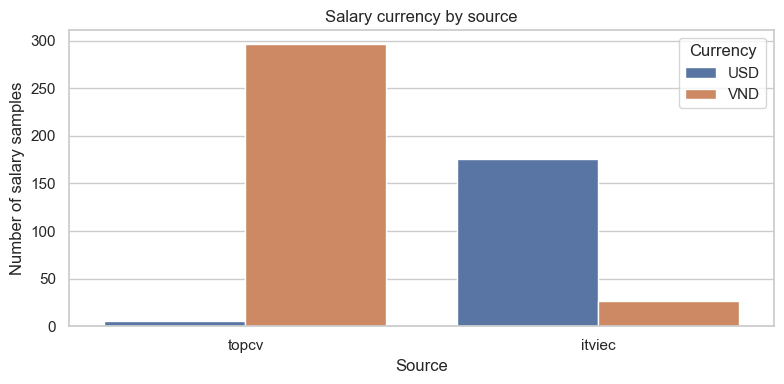

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=salary_chart, x="source", hue="salary_currency", order=source_order, ax=ax)
ax.set_title("Salary currency by source")
ax.set_xlabel("Source")
ax.set_ylabel("Number of salary samples")
ax.legend(title="Currency")
plt.tight_layout()
plt.show()

Cách đọc: nếu source này chủ yếu USD còn source kia chủ yếu VND, median salary gốc sẽ không so sánh được. Đây là lý do ta tạo `salary_monthly_vnd` trước khi phân tích hoặc model.

## 5. Histplot: Phân Phối Salary Sau Khi Convert Sang VND/Tháng

`histplot` cho biết salary tập trung ở đâu và có bị lệch phải/outlier không. Với salary data, phân phối thường skew mạnh.

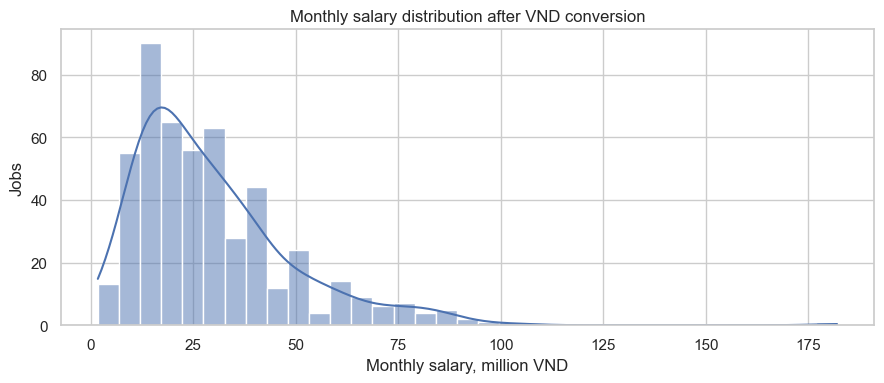

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=salary_chart, x="salary_monthly_vnd_m", bins=35, kde=True, ax=ax)
ax.set_title("Monthly salary distribution after VND conversion")
ax.set_xlabel("Monthly salary, million VND")
ax.set_ylabel("Jobs")
plt.tight_layout()
plt.show()

Cách đọc: nếu histogram dồn bên trái và kéo dài bên phải, Linear Regression trên salary gốc sẽ dễ bị vài job lương rất cao kéo lệch. Đây là dấu hiệu nên thử target dạng log.

## 6. Histplot: Log Salary

Log transform giúp salary bớt skew. Linear Regression thường ổn hơn khi target gần đối xứng hơn và outlier bớt thống trị loss.

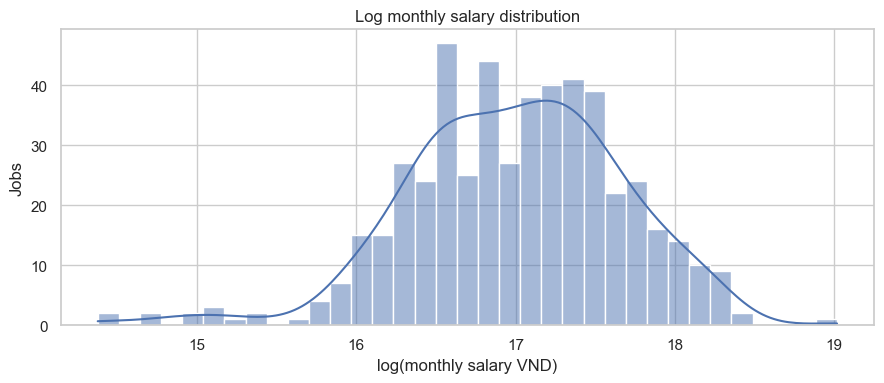

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=salary_chart, x="log_salary_monthly_vnd", bins=35, kde=True, ax=ax)
ax.set_title("Log monthly salary distribution")
ax.set_xlabel("log(monthly salary VND)")
ax.set_ylabel("Jobs")
plt.tight_layout()
plt.show()

Cách đọc: nếu log salary trông gọn hơn salary gốc, baseline Linear Regression nên dự đoán `log_salary_monthly_vnd`, sau đó convert ngược bằng `np.exp()` khi muốn đọc kết quả bằng VND.

## 7. Boxplot: Salary Theo Seniority

`boxplot` giúp xem median, khoảng IQR, và outlier theo nhóm. Đây là chart rất hữu ích để kiểm tra feature categorical có tín hiệu với salary hay không.

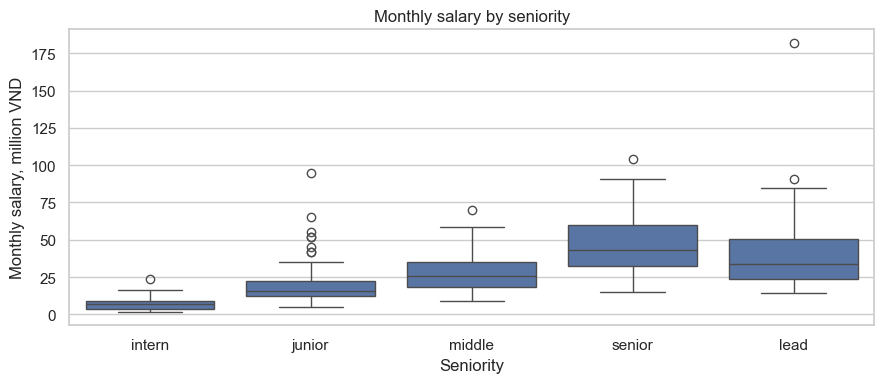

In [8]:
seniority_order = ["intern", "junior", "middle", "senior", "lead"]

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=salary_chart, x="seniority", y="salary_monthly_vnd_m", order=seniority_order, ax=ax)
ax.set_title("Monthly salary by seniority")
ax.set_xlabel("Seniority")
ax.set_ylabel("Monthly salary, million VND")
plt.tight_layout()
plt.show()

Cách đọc: đường giữa hộp là median; hộp là nhóm 50% sample ở giữa; điểm rời là outlier. Nếu median tăng từ junior đến senior/lead, `seniority` là feature tốt cho model. Nếu nhóm có quá ít sample, không nên diễn giải quá mạnh.

## 8. Boxplot: Salary Theo Source

Chart này kiểm tra source bias sau khi đã convert về VND/tháng.

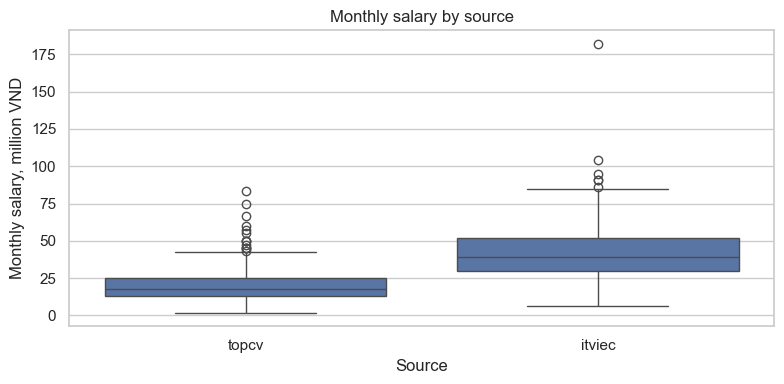

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=salary_chart, x="source", y="salary_monthly_vnd_m", order=source_order, ax=ax)
ax.set_title("Monthly salary by source")
ax.set_xlabel("Source")
ax.set_ylabel("Monthly salary, million VND")
plt.tight_layout()
plt.show()

Cách đọc: nếu một source có median cao hơn nhiều, có thể do thị trường source đó khác, hoặc do parser/source chỉ expose salary ở nhóm job khác. Khi model, `source` nên là feature và kết quả cần đánh giá theo từng source.

## 9. Scatterplot: Experience vs Salary

`scatterplot` giúp nhìn quan hệ giữa biến số và target. Với Linear Regression, ta muốn biết quan hệ có gần tuyến tính không, hay bị rất nhiễu.

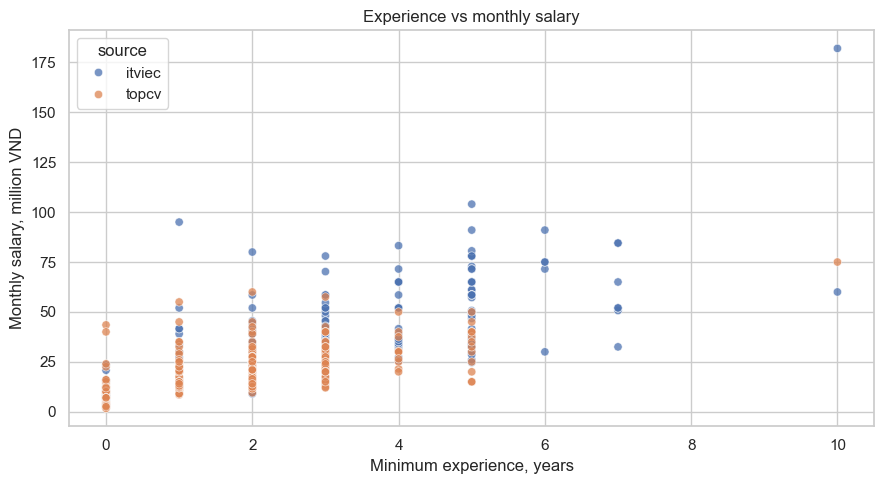

In [10]:
experience_plot = salary_chart.dropna(subset=["experience_min", "salary_monthly_vnd_m"]).copy()

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=experience_plot,
    x="experience_min",
    y="salary_monthly_vnd_m",
    hue="source",
    alpha=0.75,
    ax=ax,
)
ax.set_title("Experience vs monthly salary")
ax.set_xlabel("Minimum experience, years")
ax.set_ylabel("Monthly salary, million VND")
plt.tight_layout()
plt.show()

Cách đọc: nếu điểm đi lên khi experience tăng, biến này có tín hiệu. Nếu điểm tản rất rộng, experience một mình không đủ; cần thêm source, seniority, skills, location.

## 10. Regplot: Linear Trend Với Log Salary

`regplot` vẽ scatter và đường hồi quy tuyến tính đơn giản. Đây là cầu nối trực tiếp sang Linear Regression.

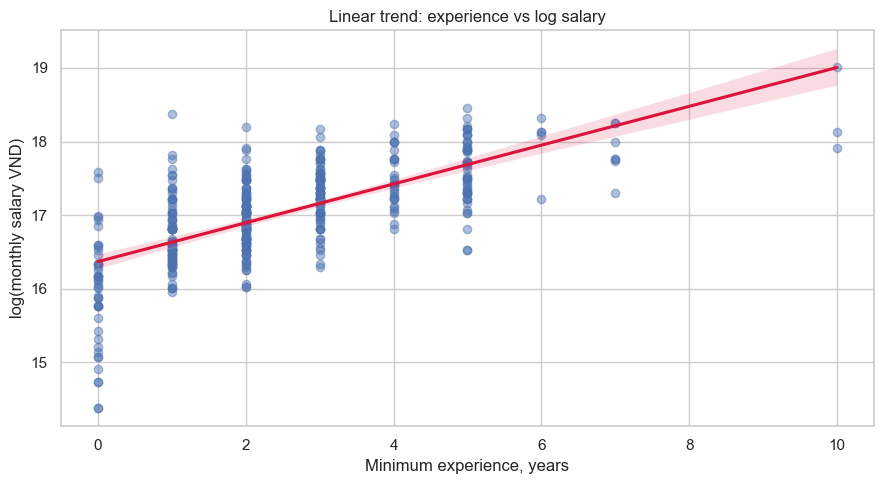

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(
    data=experience_plot,
    x="experience_min",
    y="log_salary_monthly_vnd",
    scatter_kws={"alpha": 0.45},
    line_kws={"color": "crimson"},
    ax=ax,
)
ax.set_title("Linear trend: experience vs log salary")
ax.set_xlabel("Minimum experience, years")
ax.set_ylabel("log(monthly salary VND)")
plt.tight_layout()
plt.show()

Cách đọc: đường đỏ là trend tuyến tính. Nếu đường có slope dương, experience có tác động dương trung bình. Nếu scatter quá rộng quanh đường, Linear Regression vẫn cần thêm feature và regularization.

## 11. Countplot: Top Skills

Skills sau này thường được đưa vào model bằng one-hot encoding. Trước đó cần xem skill nào có đủ sample. Skill quá hiếm dễ gây overfit.

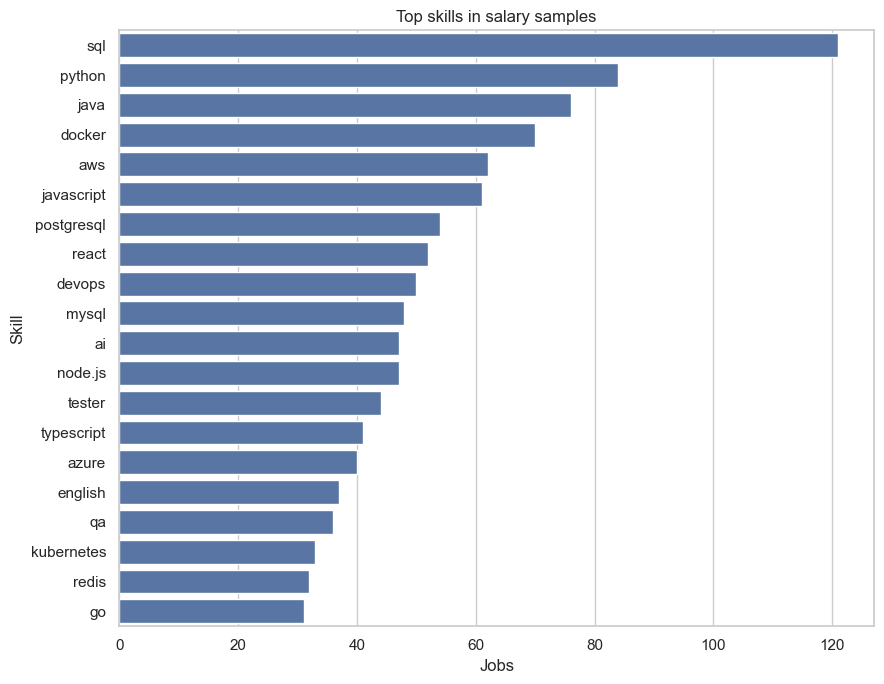

In [12]:
salary_skills = (
    salary_chart[["url", "source", "title", "salary_monthly_vnd_m", "skills_norm_list"]]
    .explode("skills_norm_list", ignore_index=True)
    .rename(columns={"skills_norm_list": "skill_norm"})
)
salary_skills = salary_skills.loc[salary_skills["skill_norm"].notna() & salary_skills["skill_norm"].ne("")].copy()
top_skill_order = salary_skills["skill_norm"].value_counts().head(20).index

fig, ax = plt.subplots(figsize=(9, 7))
sns.countplot(data=salary_skills[salary_skills["skill_norm"].isin(top_skill_order)], y="skill_norm", order=top_skill_order, ax=ax)
ax.set_title("Top skills in salary samples")
ax.set_xlabel("Jobs")
ax.set_ylabel("Skill")
plt.tight_layout()
plt.show()

Cách đọc: chỉ nên đưa nhiều skill vào Linear Regression nếu sample đủ lớn. Một rule đơn giản cho baseline: bắt đầu với top 20-30 skills, sau đó dùng Ridge để giảm overfit.

## 12. Heatmap: Missing Values

Missing values không xấu, nhưng model cần biết cột nào thiếu nhiều để impute hoặc loại bỏ. Heatmap giúp nhìn pattern thiếu dữ liệu.

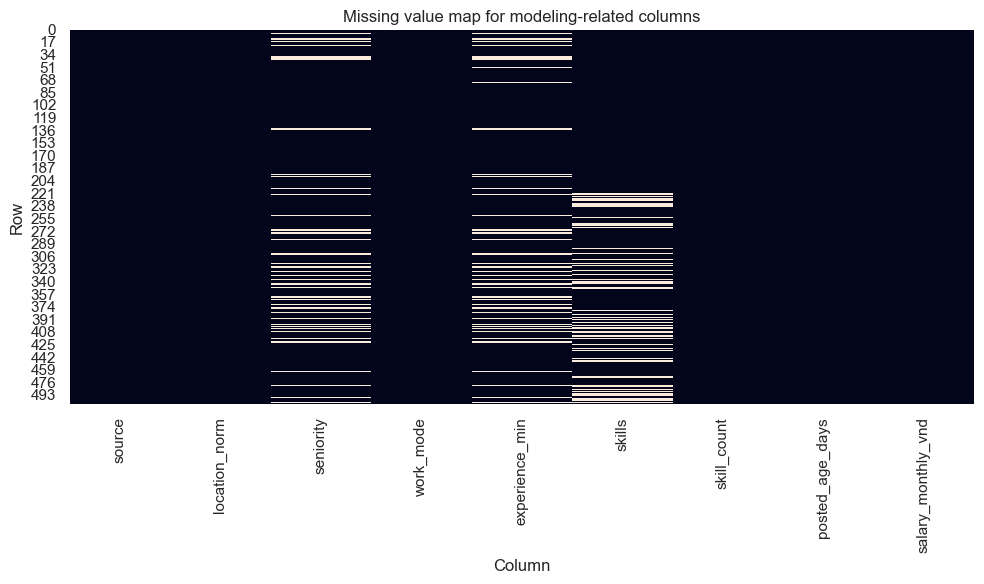

,column,missing_rate
0,skills,0.162698
1,experience_min,0.138889
2,seniority,0.130952
3,source,0.000000
4,location_norm,0.000000
5,work_mode,0.000000
6,skill_count,0.000000
7,posted_age_days,0.000000
8,salary_monthly_vnd,0.000000


In [17]:
missing_columns = [
    "source",
    "location_norm",
    "seniority",
    "work_mode",
    "experience_min",
    "skills",
    "skill_count",
    "posted_age_days",
    "salary_monthly_vnd",
]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(salary_chart[missing_columns].isna(), cbar=False, ax=ax)
ax.set_title("Missing value map for modeling-related columns")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.tight_layout()
plt.show()

missing_summary = (
    salary_chart[missing_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename_axis("column")
    .reset_index(name="missing_rate")
)
display(missing_summary)

Cách đọc: cột nào missing nhiều cần xử lý trước khi model. Với Linear Regression, numeric có thể impute median, categorical có thể impute `Unknown`, nhưng nếu missing phản ánh parser lỗi thì nên sửa parser trước.

## 13. Heatmap: Correlation Numeric Features

Correlation heatmap giúp xem numeric feature nào có quan hệ tuyến tính với target. Đây không phải bằng chứng nhân quả, chỉ là tín hiệu ban đầu.

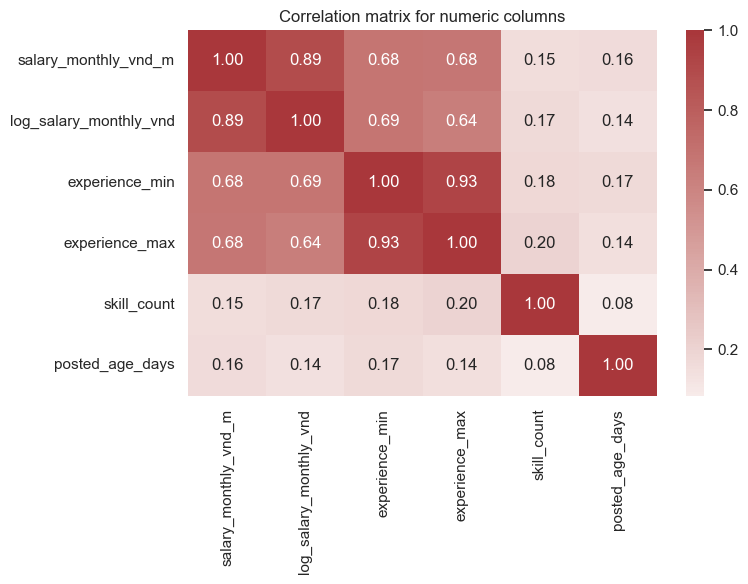

In [16]:
numeric_for_corr = [
    "salary_monthly_vnd_m",
    "log_salary_monthly_vnd",
    "experience_min",
    "experience_max",
    "skill_count",
    "posted_age_days",
]
corr = salary_chart[numeric_for_corr].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation matrix for numeric columns")
plt.tight_layout()
plt.show()

Cách đọc: correlation gần 1 hoặc -1 là quan hệ tuyến tính mạnh; gần 0 là yếu. Nếu `experience_min` chỉ correlation vừa phải với salary, đó là bình thường: salary còn phụ thuộc vào source, skill, seniority, city, company và job type.

## 14. Kết Luận Cho Linear Regression

Sau notebook này, hướng đi hợp lý cho baseline model là:

- Target: dùng `log_salary_monthly_vnd`, không dùng salary gốc.
- Feature nên dùng trước: `source`, `location_norm`, `seniority`, `work_mode`, `experience_min`, `skill_count`, top skill flags, `posted_age_days`.
- Không dùng feature leakage: `salary_raw`, `salary_min`, `salary_max`, `salary_midpoint`, `salary_currency`, `salary_period`, `salary_label`.
- Không dùng `location_cities` hiện tại vì field này đang bị nhiễu.
- Trước khi update data lớn cho XGBoost, nên sửa parser `salary_period` và location extraction.